# Step 5. Ethics and Bias Audit

This is where the dataset choice pays off. Step 5 opens the model up, states its limits, and checks whether it treats groups fairly.

I do four things.

1. Explain how the model decides, using SHAP.
2. State the model's limits honestly.
3. Audit the model for bias across the four sensitive attributes.
4. Apply two mitigations to one attribute, and show what they cost.

It loads the logistic regression chosen in Step 4, and the cutoff chosen with it. Being a simple, readable model, it makes the explanation clean.

Two things in this notebook were wrong the first time round, and both were wrong quietly. The SHAP chart was ranking the wrong things. And the fairness audit was asking a question that, for three of the four attributes, does not have a fair answer. Sections 1 and 3 work through both.

In [1]:
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "paths.py").exists():
        sys.path.insert(0, str(_p))
        break

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
from src.paths import ROOT
from src.features import group_shap_by_feature, MODEL_NOMINAL

model = joblib.load(ROOT / "models" / "model.joblib")
metrics = json.load(open(ROOT / "models" / "metrics.json"))
THRESHOLD = metrics["operating_threshold"]

proc = ROOT / "data" / "processed"
train = pd.read_csv(proc / "train.csv")
test = pd.read_csv(proc / "test.csv")
ytr = train.pop("dropout")
yte = test.pop("dropout")
Xtr, Xte = train, test

# The audit runs at the cutoff Step 4 chose, not at the 0.5 default. Fairness metrics
# are all threshold-dependent, so auditing at a cutoff nobody picked would audit a
# model nobody is going to deploy.
y_proba = model.predict_proba(Xte)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)
print(f"loaded model at threshold {THRESHOLD}. test", Xte.shape)

loaded model at threshold 0.445. test (726, 31)


## 1. How the Model Decides

A model that scores students should be able to say why. SHAP does this. SHAP gives each feature a value for each student, the push it gave to that student's risk score, up or down. Averaged over all students, it shows which features drive the model most.

SHAP fits a linear model cleanly, since each feature already has a weight. For a linear model the SHAP value of a column is just its coefficient times how far the student sits from average on it, so the chart is a direct read of what the model does.

My first version of this chart was wrong, and wrong in a way that was hard to see.

It plotted one bar per column of the design matrix. But `Course` is not a column. It is seventeen one-hot columns. So its importance got chopped into seventeen small bars, none of them big enough to notice, while a single flag like tuition status kept all of its weight in one place. High-cardinality features were being buried by the encoding, and I was reading the result as if it meant something.

The fix is to add each categorical's pieces back together before ranking. Both versions are below, because the difference between them is the point.

per encoded column, the way I plotted it the first time
flag__Tuition fees up to date    0.680
flag__Scholarship holder         0.507
flag__mature entry               0.436
flag__Gender                     0.301
cat__Course_9500                 0.284
num__Admission grade             0.245

summed back onto the original feature
Course                     1.126
Tuition fees up to date    0.680
mother isco                0.509
Scholarship holder         0.507
mature entry               0.436
Gender                     0.301
father isco                0.282
application route          0.276
Admission grade            0.245
Unemployment rate          0.190


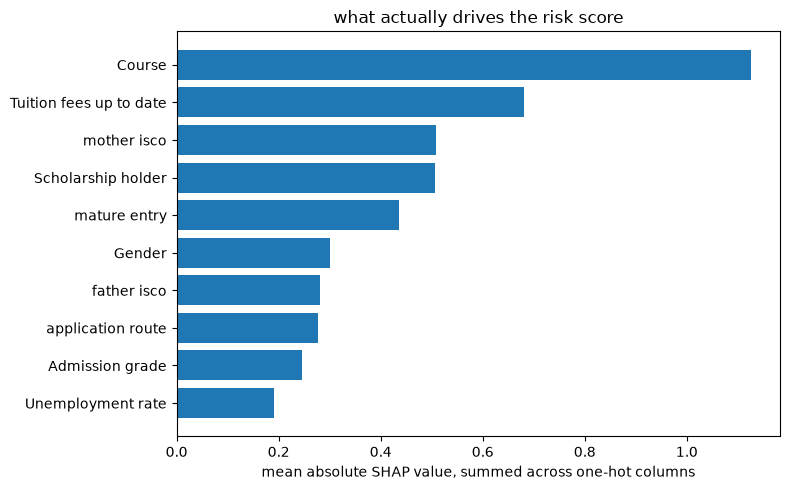

In [2]:
import shap

pre = model.named_steps["pre"]
lr = model.named_steps["m"]
dense = lambda M: M.toarray() if hasattr(M, "toarray") else M
Ztr, Zte = dense(pre.transform(Xtr)), dense(pre.transform(Xte))
names = list(pre.get_feature_names_out())

# The background set has to be the whole training set, and it has to be said out loud.
# Handed a bare array, LinearExplainer quietly subsamples it to 100 rows, unseeded, and
# the numbers then move a little on every run. Tuition status came out at 0.90 one run
# and 0.68 the next. An explanation that changes when nothing changed is not an
# explanation.
masker = shap.maskers.Independent(Ztr, max_samples=Ztr.shape[0])
shap_values = shap.LinearExplainer(lr, masker).shap_values(Zte)

# The old chart: one bar per encoded column.
per_column = pd.Series(np.abs(shap_values).mean(0), index=names).sort_values(ascending=False)

# The fixed chart: every one-hot dummy summed back onto the feature it came from.
per_feature = group_shap_by_feature(shap_values, names)

print("per encoded column, the way I plotted it the first time")
print(per_column.head(6).round(3).to_string())
print("\nsummed back onto the original feature")
print(per_feature.head(10).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
top = per_feature.head(10)[::-1]
ax.barh(top.index, top.values)
ax.set_xlabel("mean absolute SHAP value, summed across one-hot columns")
ax.set_title("what actually drives the risk score")
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "shap_importance.png", dpi=90)
plt.show()

**Course is the strongest thing the model uses**, by a wide margin, at 1.126. It did not appear anywhere in the first version of this section. Neither did mother's occupation, which now sits **third** at 0.509, ahead of scholarship status.

That changes what this notebook is about.

The story I had was a money story. Tuition, scholarship, debt. It is still there and it is still strong, and tuition status sits second at 0.680. But the thing above it is **which course a student enrolled in**, and the thing directly below it is **what their mother does for a living**.

Those are not warnings a student can act on. Nobody chooses their mother's occupation, and by the time the model runs, the course is already picked.

So the model is not mostly finding students in trouble. It is substantially finding students who **started from further back**. Section 3 is where that stops being an observation and becomes a fairness question.

Gender is in there too, at 0.301, which means the model uses gender directly. The audit below comes back to that.

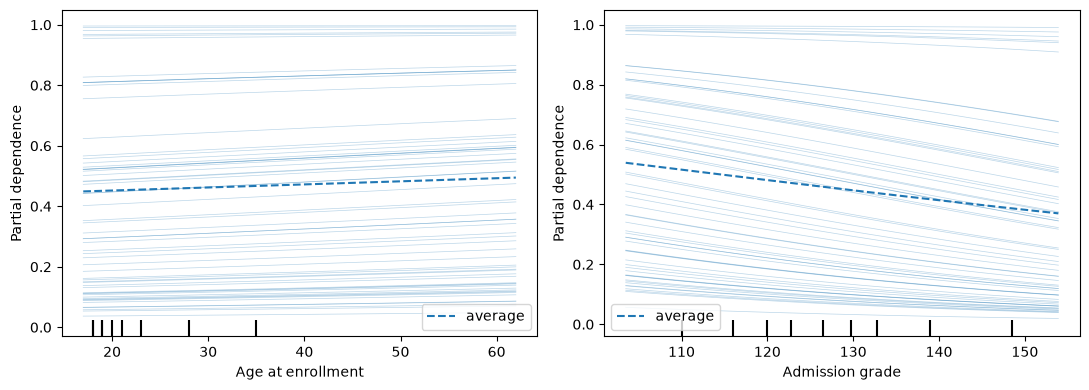

In [3]:
from sklearn.inspection import PartialDependenceDisplay

# PDP needs float columns, so I cast the two features I plot.
Xpdp = Xtr.copy()
for c in ["Age at enrollment", "Admission grade"]:
    Xpdp[c] = Xpdp[c].astype(float)

# kind="both" draws the ICE lines as well as the average. The average can hide a
# feature that pushes half the students one way and half the other.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(model, Xpdp, ["Age at enrollment"], kind="both",
                                        subsample=60, random_state=42, ax=ax[0])
PartialDependenceDisplay.from_estimator(model, Xpdp, ["Admission grade"], kind="both",
                                        subsample=60, random_state=42, ax=ax[1])
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "pdp.png", dpi=90)
plt.show()

Risk climbs with age at enrollment and falls as admission grade rises. Both move in the direction Step 3 predicted, so nothing surprising there.

The thin lines are the ICE curves, one per student, and they are the reason this plot is worth drawing rather than just quoting the average. A partial dependence line is a mean, and a mean can hide a feature that pushes half the students one way and half the other while averaging out to a flat line. Here the individual lines all run parallel, which is what a linear model with no interactions should look like. That is a check passing, not a finding, and it is still worth having on the page.

## 2. The Limits

An honest audit names what could go wrong.

Imbalance. The dropout rate is 39 percent, mildly uneven. Class weights handled it, and PR AUC leads, which stays honest on uneven data. So imbalance is handled, not ignored.

Leakage. The biggest guard. The model trained on enrollment-time features only, with the twelve curricular columns dropped, since they record the outcome as it happens. Tuition status is a softer case, a near-outcome signal kept but watched, and Step 3 measured its effect on training folds rather than on the test set.

Unreadable coefficients. This limit is here because it nearly ruined this notebook. Every explanation below is read off the model's weights, so a weight carrying the wrong sign becomes a sentence that tells a student the opposite of the truth. Step 3 found nineteen exact linear dependencies in the design matrix I started with, and two coefficients whose signs had flipped as a result. The fixed matrix has six dependencies against six one-hot blocks, which is the number the encoding puts there by construction and not one more. That rank check is now a standing guard rather than a one-off, because nothing in this notebook can be trusted without it.

Overfitting. Checked below, by comparing the model on the training set against the test set.

Scope. From Step 1, this model fits an IPP style Portuguese polytechnic, not any school anywhere. The results do not transfer to a very different institution.

In [4]:
from sklearn.metrics import average_precision_score

train_pr = average_precision_score(ytr, model.predict_proba(Xtr)[:, 1])
test_pr = average_precision_score(yte, y_proba)
print("PR AUC on train", round(train_pr, 3))
print("PR AUC on test ", round(test_pr, 3))
print("gap", round(train_pr - test_pr, 3))

PR AUC on train 0.84
PR AUC on test  0.822
gap 0.018


The gap between train and test PR AUC is small, 0.840 against 0.822. A small gap means the model learned the pattern, not the noise, so it is not badly overfit. The class weights and the simple linear model both help keep it steady.

## 3. The Fairness Audit, and the Metric I Was Using Wrong

The first version of this audit ran demographic parity on all four attributes, found every one of them below the 0.8 disparate impact line, and concluded that the model fails on all four.

That conclusion was too easy, and it was partly wrong.

**Demographic parity** asks whether the model flags each group at the same rate. That is the right question when the groups do not really differ. It is the wrong question when they do. Debtors drop out at 76 percent and non-debtors at 34. Demanding that the model flag both groups equally would be demanding that the model ignore a 42-point difference it can plainly see. That is not fairness. That is asking to be wrong on purpose.

So the real-world gap goes into the table too, sitting right next to the metric. The comparison is the whole point. If the model's flagging gap is roughly the size of the actual outcome gap, the model is **reporting** a disparity. If the flagging gap is bigger, the model is **making** one. Those are different things, and lumping them together under one 0.8 threshold hides the difference.

**Equalized odds** asks the question that survives a real base-rate difference. Not "does the model flag both groups equally" but "does the model make its mistakes equally". A model can be right about a gap and still be unfair about who it fails, and that turns out to be exactly what is happening here.

**Equal opportunity difference** narrows that to the error that matters most for this tool. The gap in recall. Of the students who actually drop out, does the model catch the same share in every group?

**Disparate impact ratio** stays in, because the 0.8 bar is a real regulatory convention and worth reporting. It just does not get to deliver the verdict on its own any more.

In [5]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    demographic_parity_ratio, equal_opportunity_difference,
    selection_rate, true_positive_rate, false_positive_rate,
)

age_band = pd.cut(Xte["Age at enrollment"], [16, 20, 23, 30, 100],
                  labels=["17 to 20", "21 to 23", "24 to 30", "31 plus"])
attrs = {
    "Gender": Xte["Gender"].map({1: "male", 0: "female"}),
    "Scholarship": Xte["Scholarship holder"].map({1: "holder", 0: "none"}),
    "Debtor": Xte["Debtor"].map({1: "debtor", 0: "not debtor"}),
    "Age band": age_band,
}

rows = []
for name, sf in attrs.items():
    # The real gap. How differently do these groups ACTUALLY behave? Without this
    # column the metrics below cannot be read.
    real = yte.groupby(sf.values, observed=True).mean()
    rows.append({
        "attribute": name,
        "real gap in outcomes": round(real.max() - real.min(), 3),
        "flagging gap (DP)": round(demographic_parity_difference(yte, y_pred, sensitive_features=sf), 3),
        "DI ratio": round(demographic_parity_ratio(yte, y_pred, sensitive_features=sf), 3),
        "error gap (EO)": round(equalized_odds_difference(yte, y_pred, sensitive_features=sf), 3),
        "recall gap": round(equal_opportunity_difference(yte, y_pred, sensitive_features=sf), 3),
    })
audit = pd.DataFrame(rows)
print(audit.to_string(index=False))

print()
print("gender, per group")
mf = MetricFrame(
    metrics={"flag rate": selection_rate, "recall": true_positive_rate, "false alarm": false_positive_rate},
    y_true=yte, y_pred=y_pred, sensitive_features=attrs["Gender"],
)
print(mf.by_group.round(3))

  attribute  real gap in outcomes  flagging gap (DP)  DI ratio  error gap (EO)  recall gap
     Gender                 0.238              0.350     0.496           0.290       0.177
Scholarship                 0.318              0.500     0.171           0.385       0.283
     Debtor                 0.392              0.369     0.545           0.199       0.199
   Age band                 0.433              0.558     0.369           0.572       0.253

gender, per group
        flag rate  recall  false alarm
Gender                                
female      0.345   0.700        0.195
male        0.694   0.877        0.485


Read the first two number columns against each other. That comparison is the whole audit.

**Debtor.** Real gap 0.392. Flagging gap 0.369. The disparity the model produces is *smaller* than the one already in the world. It is under-reporting a real difference, not inventing one. Its disparate impact ratio of 0.545 sits well below the 0.8 line, and the first version of this notebook called that a failure. It is not a failure. It is a 42-point difference in who actually leaves, showing up in a model that was built to find who actually leaves. Debt is not a protected class, and equal flagging across it is not something anyone should want.

**Scholarship** is the same shape. Real gap 0.318, and the model tracks it.

**Gender is the opposite.** Real gap 0.238. Flagging gap **0.350**. The gap the model creates is *bigger* than the gap in the world. That is amplification, and gender is the one attribute here where demographic parity asks exactly the right question and gets back a bad answer.

**Age band** amplifies too, and carries the largest error gap of all four at 0.572. But age also has the largest genuine base-rate difference, 0.433, and `mature entry` is a feature I built on purpose because that difference is real. It is a harder case, and it needs its own pass.

So gender is where the mitigation goes. It is the clearest case, and it is a protected attribute in a way that debt and scholarship status are not.

But the per-group numbers underneath tell a different story from the one I expected, and it is a worse one.

Here is the harm, and it is not the one I went looking for.

The model flags 69 percent of male students and 35 percent of female students. That looks like men being over-policed, and in one sense they are. Their false alarm rate is 0.485 against 0.195 for women, so a man who was going to graduate perfectly well is more than twice as likely to be pulled into a retention conversation he did not need.

But look at recall. **0.877 for men. 0.700 for women.**

Three in ten women who go on to drop out are never flagged at all. For men it is barely one in ten.

That is the finding. Not "every attribute fails disparate impact", which was true and useless. The model is quietly worse at its actual job for women than for men. The students this tool exists to reach are being missed, and they are being missed unevenly. No amount of staring at flagging rates would have shown that. It only appears once you stop counting flags and start counting **errors**.

Whether the model should be looking at gender at all is a separate question, and the answer is not the obvious one. Dropping the column does not remove gender from the model, because the model still sees Course, and Section 1 showed Course is the single strongest thing it uses. Courses in this data are heavily gendered. Removing a protected attribute from a model that keeps its proxies makes the bias harder to measure without making it any smaller.

## 4. Mitigation

All four attributes cannot be fixed at once, since pushing one into balance can pull another out. Gender is the one that gets fixed, for the reasons in Section 3. It is the attribute the model amplifies rather than reports, and it is protected in a way that debt and scholarship status are not.

Both methods target **equalized odds**, not demographic parity. The first version of this notebook pointed one of them at demographic parity, which was the wrong target. The harm here is an error gap, so the constraint has to be on errors.

Threshold optimizer. A post-processing method. It keeps the model exactly as it is and picks a separate cutoff for each group.

Exponentiated gradient. An in-processing method. It retrains the model under the fairness constraint, so the constraint shapes the weights rather than just the cutoff.

One is cheap, one is thorough. Neither is free, and the cost is the point of the table.

In [6]:
from sklearn.metrics import recall_score, precision_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

g_tr = Xtr["Gender"].map({1: "male", 0: "female"})
g_te = attrs["Gender"]

def fairness_row(name, pred):
    return {
        "approach": name,
        "recall": round(recall_score(yte, pred), 3),
        "precision": round(precision_score(yte, pred), 3),
        "accuracy": round(accuracy_score(yte, pred), 3),
        "flagging gap": round(demographic_parity_difference(yte, pred, sensitive_features=g_te), 3),
        "error gap": round(equalized_odds_difference(yte, pred, sensitive_features=g_te), 3),
        "recall gap": round(equal_opportunity_difference(yte, pred, sensitive_features=g_te), 3),
    }

rows = [fairness_row(f"baseline at {THRESHOLD:.2f}", y_pred)]

# Post-processing. Keeps the model, moves the cutoff per group.
to = ThresholdOptimizer(estimator=model, constraints="equalized_odds",
                        predict_method="predict_proba", prefit=True)
to.fit(Xtr, ytr, sensitive_features=g_tr)
rows.append(fairness_row("threshold optimizer",
                         to.predict(Xte, sensitive_features=g_te, random_state=42)))

# In-processing. Retrains under the constraint, so the weights themselves change.
#
# random_state on predict is not optional here. ExponentiatedGradient does not return
# one classifier, it returns a weighted mixture of several, and predict() draws from
# that mixture at random. Without a seed the recall gap came back as 0.012 one run and
# 0.001 the next, off the same fitted object. A fairness number that moves when nothing
# moved is not a fairness number.
eg = ExponentiatedGradient(LogisticRegression(max_iter=3000, class_weight="balanced"),
                           constraints=EqualizedOdds())
eg.fit(Ztr, ytr, sensitive_features=g_tr)
rows.append(fairness_row("exponentiated gradient", eg.predict(Zte, random_state=42)))

mitigation = pd.DataFrame(rows)
print(mitigation.to_string(index=False))

              approach  recall  precision  accuracy  flagging gap  error gap  recall gap
      baseline at 0.45   0.796      0.644     0.748         0.350      0.290       0.177
   threshold optimizer   0.609      0.783     0.781         0.100      0.026       0.026
exponentiated gradient   0.718      0.685     0.760         0.131      0.027       0.009


Both land in almost exactly the same place on fairness. And then they charge wildly different prices for it.

On the error gap they are level. The threshold optimizer gets it to 0.026, the exponentiated gradient to 0.027. On the recall gap, the one that measures the harm I actually found, the reduction is the better of the two, 0.009 against 0.026. Either way, both close a gap that started at 0.177. Fairness is a wash.

The cost is not a wash at all.

**The threshold optimizer** drops recall from 0.796 to **0.609**. Nineteen points, gone. Look at how it got there. It closed the gap between men and women largely by catching fewer people, so it bought fairness by missing more students of both kinds. Accuracy went *up* while the tool got *worse* at its job, which is a useful reminder of how little accuracy is worth on a problem shaped like this one.

**The exponentiated gradient** drops recall from 0.796 to **0.718**. Eight points. Same fairness, less than half the price, and what comes out the other side is still a logistic regression that can explain itself.

**Take the exponentiated gradient.** Eight points of recall is a real cost and it should be written down plainly rather than buried. It means roughly thirty fewer leavers caught per thousand students. What it buys is that those thirty are not disproportionately women, and that the tool is no longer measurably worse at helping the group it was already failing.

The other option was to fix the gap by helping fewer people. That is not a fix.

## 5. Residual Risk, and What I Would Tell the School

The model works, and it works on things students cannot change.

Course comes first. Mother's occupation comes third. Tuition and scholarship status, which are money problems the school can actually do something about, sit around them. So this is not a tool that spots trouble brewing. It is largely a tool that recognises students who started from further back, and the school should be honest with itself about that before it deploys anything.

Which suggests the flag is the wrong shape for the intervention. Step 4 reached the same conclusion from the economics. A ranked list, read from the top, with the reason attached, is something a tutor can work with. A binary at-risk label attached to a student's record is something that follows them around.

Gender is mitigated. Scholarship, debtor, and age band are not, and for the first two that is the right call, because their gaps are real and the model is reporting them rather than inventing them. Age band is genuinely unresolved and needs its own pass.

Three things I would insist on before this goes anywhere near a student.

**The score is never shown to the student as a number.** A person told they are 78 percent likely to fail has been handed a prediction, not help.

**Anything the score is built from that the school could change, the school should change.** Tuition status is the second strongest signal in the model, and a payment plan is a cheaper intervention than a tutor.

**The recall gap gets re-measured every intake.** It was 0.177 on this cohort. It is not the kind of thing that stays fixed on its own.

## What Step 5 Settles

1. SHAP, once the one-hot columns are summed back onto their features, shows the model leans hardest on **Course**, then tuition status, then **mother's occupation**, then scholarship. The first version of this chart ranked encoded columns and buried both of the ones that matter. It was also reading a 100-row subsample of the background set, unseeded, so its numbers moved on every run.
2. The limits are named. Mild imbalance handled, leakage guarded, collinearity checked by rank, small overfitting gap, single-institution scope.
3. The fairness audit stopped treating demographic parity as a verdict. For debtor and scholarship the model **reports** a real gap. For gender it **amplifies** one, and that is the difference the old audit could not see.
4. The harm is a recall gap. **0.877 for men, 0.700 for women.** Three in ten women who drop out are never flagged.
5. Two mitigations were measured at the chosen threshold, both seeded so the numbers hold still. They reach the same fairness. The exponentiated gradient charges eight points of recall for it and the threshold optimizer charges nineteen, so the reduction ships.
6. The residual risk is stated plainly, so the model gets used with care rather than blind trust.

This closes the core seven steps. The bonus work, deployment and a GenAI explanation layer, builds on the model saved here, and on the SHAP values this notebook now computes correctly.